# Patrón 3: Hierarchical Multi-Agent — Customer Support Ticket System

Dataset: Tobi-Bueck/customer-support-tickets — 61,800 tickets reales con campos subject, body, type, queue, priority, answer, language.

Arquitectura:

* Root Orchestrator → recibe el ticket y decide el dominio
* Subgraph Billing → agentes: analizador + respondedor de facturación
* Subgraph Technical → agentes: diagnóstico + solución técnica
* Subgraph General → agente: respondedor general

|Nivel|Nodo|Rol|
|:----|:---|:--|
|Root|root_orchestrator|Clasifica el ticket en billing / technical / general|
|Sub-orq. Billing|billing_analyzer|Identifica tipo de problema financiero|
|Hoja Billing|billing_responder|Genera respuesta al cliente de facturación|
|Sub-orq. Technical|tech_diagnostics|Diagnostica componente y causa raíz|
|Hoja Technical|tech_solution_writer|Redacta solución técnica con pasos|
|Sub-orq. General|general_responder|Responde consultas generales|
|Root (final)|quality_checker|Revisa y pule la respuesta antes de enviar|


Dataset:

* Dataset - Customer Support Tickets (HuggingFace / Kaggle)
* Dataset URL : https://www.kaggle.com/datasets/tobiasbueck/multilingual-customer-support-tickets
* Mirror URL:  https://huggingface.co/datasets/Tobi-Bueck/customer-support-tickets
* 61,800 tickets con: subject, body, answer, type, queue, priority, language

Dependencias:
```bash
!pip install langgraph langchain langchain-anthropic langchain-community datasets pandas --quiet
```


Diagrama del caso de uso:

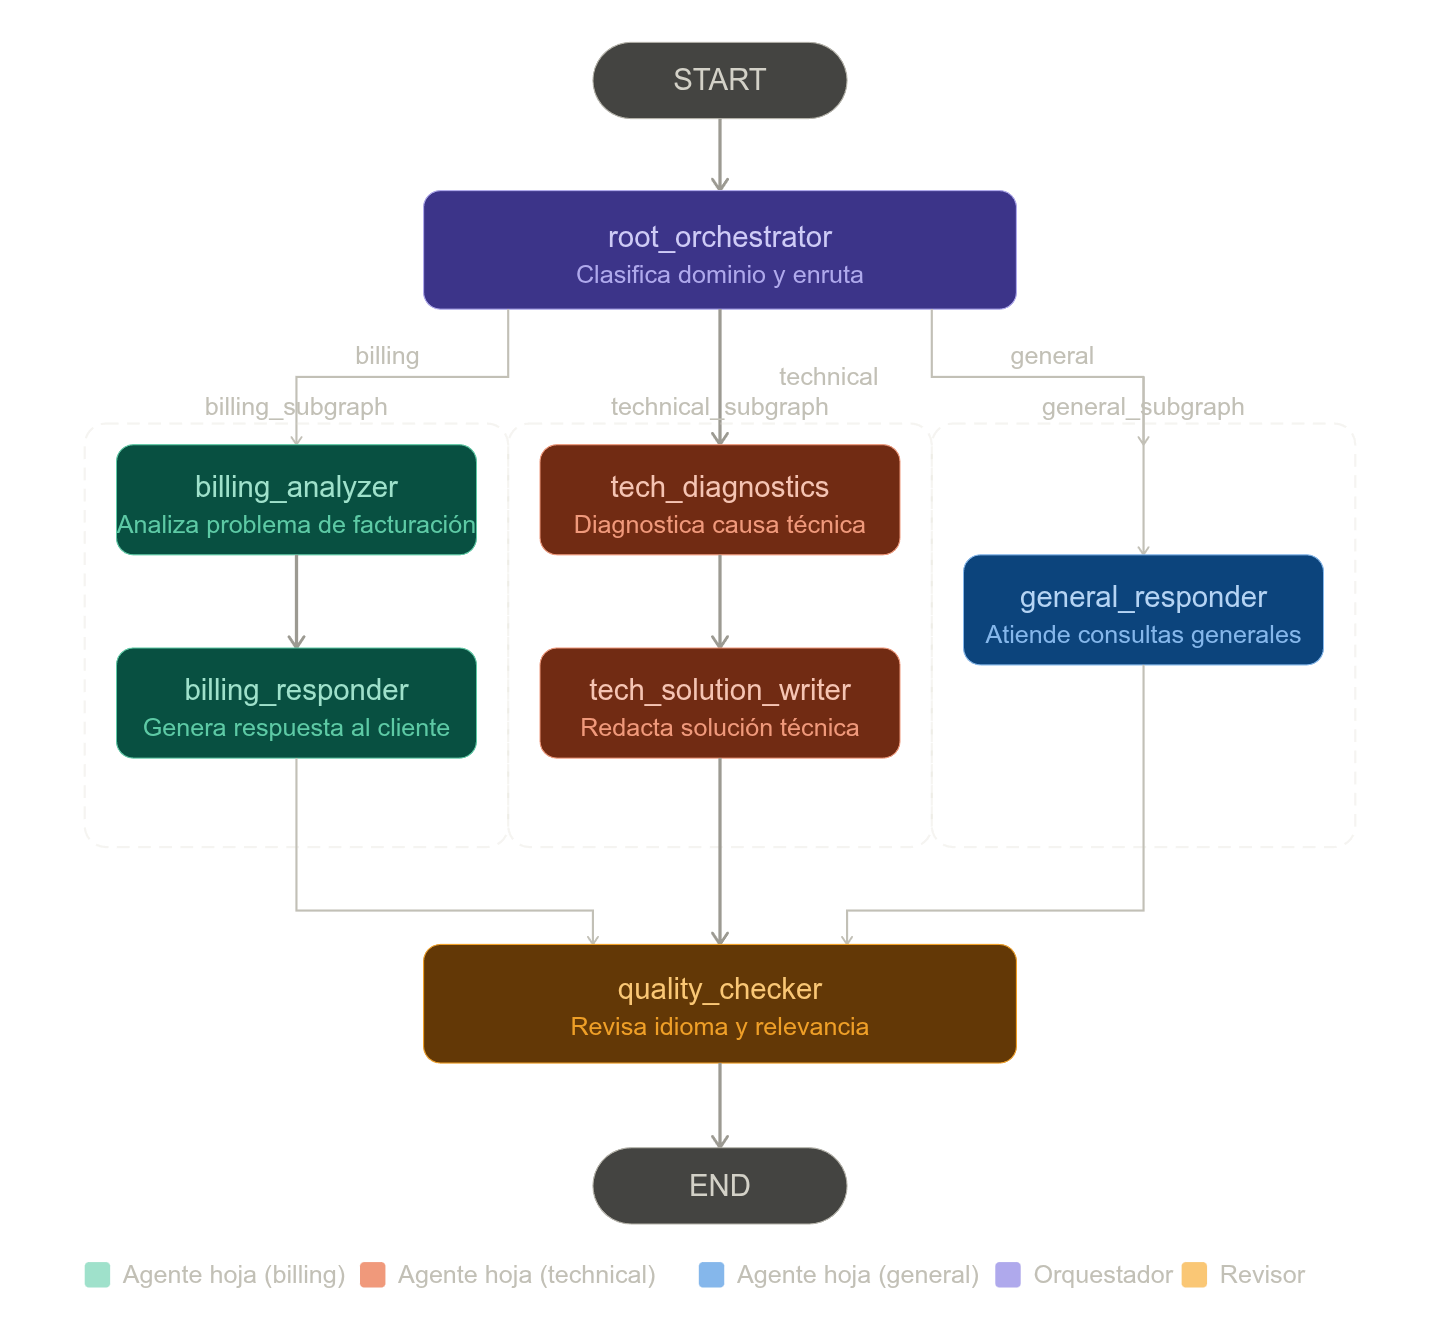

Nodos:
|Nodo/Componente|Tipo|Función|Descripción|
|:--------------|:---|:------|:----------|
|START|Punto de Entrada|Iniciar el grafo|Nodo especial de LangGraph que dispara la ejecución pasando el TicketState inicial con ticket_subject, ticket_body y ticket_language|
|root_orchestrator|Orquestador raíz (Root)|Clasificar y enrutar|Invoca el LLM para clasificar el ticket en billing, technical o general y determinar la prioridad. Popula domain, priority_detected y routing_reason en el estado|
|billing_subgraph|Sub-orquestador (Subgraph)|Contener el flujo de facturación|Subgrafo compilado independiente que encapsula los dos agentes hoja de billing. Recibe el estado completo y lo devuelve con analysis y draft_response poblados|
|billing_analyzer|Agente hoja (Leaf)|Analizar el problema de facturación|Identifica el tipo de problema financiero, datos disponibles y nivel de riesgo. Trabaja exclusivamente sobre el texto del ticket, sin inventar datos. Popula analysis|
|billing_responder|Agente hoja (Leaf)|Generar respuesta de facturación|Produce la respuesta al cliente usando el análisis previo como contexto. Respeta el idioma detectado vía lang_instruction. Popula draft_response|
|technical_subgraph|Sub-orquestador (Subgraph)|Contener el flujo técnico|Subgrafo compilado que encapsula el diagnóstico y la redacción de solución técnica. Aislado del resto del grafo para separar fallos|
|tech_diagnostics|Agente hoja (Leaf)|Diagnosticar causa técnica|Identifica componentes afectados y severidad basándose solo en el texto del ticket. Si la causa no está especificada, lo indica explícitamente en lugar de inferir. Popula analysis|
|tech_solution_writer|Agente hoja (Leaf)|Redactar solución técnica|Escribe la respuesta con pasos numerados basada en el diagnóstico y el ticket original. Si la causa es desconocida, solicita información adicional al cliente. Popula draft_response|
|general_subgraph|Sub-orquestador (Subgraph)|Contener el flujo general|Subgrafo con un único agente hoja para consultas generales, devoluciones e información de productos|
|general_responder|Agente hoja (Leaf)|Atender consultas generales|Responde consultas que no son billing ni technical. Respeta el idioma del cliente y no asume información no mencionada en el ticket. Popula analysis y draft_response|
|quality_checker|Revisor final (Root)|Revisar y pulir la respuesta|Nodo convergente donde llegan los tres subgraphs. Verifica que la respuesta corresponda al ticket original, corrige el idioma si no coincide y elimina información irrelevante. Popula final_response|
|END|Punto de salida|Terminar el grafo|Nodo especial de LangGraph que finaliza la ejecución y retorna el TicketState completo con final_response lista para entregar al cliente|
|route_by_domain|Edge condicional (Router)|Enrutar entre subgraphs|Función pura (no es un nodo LLM) que lee state["domain"] y retorna el nombre del subgraph destino. Implementa el add_conditional_edges del root orchestrator|
|lang_instruction|Helper (Utility)|Inyectar instrucción de idioma|Función utilitaria que lee state["ticket_language"] y retorna la instrucción de idioma correspondiente. Es llamada desde cada agente hoja antes de invocar el LLM

### Cuándo usarlo
- ✅ Sistemas empresariales con múltiples dominios
- ✅ Equipos grandes de agentes (>10 workers)
- ✅ Cuando cada dominio necesita su propia lógica de coordinación
- ✅ Aislamiento de fallos por subgraph
- ❌ Overhead de latencia por múltiples niveles de LLM calls

In [1]:
!pip install langgraph langchain langchain-anthropic langchain-community datasets pandas --quiet

error: externally-managed-environment

× This environment is externally managed
╰─> To install Python packages system-wide, try apt install
    python3-xyz, where xyz is the package you are trying to
    install.
    
    If you wish to install a non-Debian-packaged Python package,
    create a virtual environment using python3 -m venv path/to/venv.
    Then use path/to/venv/bin/python and path/to/venv/bin/pip. Make
    sure you have python3-full installed.
    
    If you wish to install a non-Debian packaged Python application,
    it may be easiest to use pipx install xyz, which will manage a
    virtual environment for you. Make sure you have pipx installed.
    
    See /usr/share/doc/python3.14/README.venv for more information.

note: If you believe this is a mistake, please contact your Python installation or OS distribution provider. You can override this, at the risk of breaking your Python installation or OS, by passing --break-system-packages.
hint: See PEP 668 for the detai

In [2]:
from dotenv import load_dotenv
load_dotenv()

True

In [3]:
import pandas as pd
from IPython.display import display, Markdown,Image
from typing import TypedDict, Literal, Optional, Annotated
import operator
import json

In [4]:
from datasets import load_dataset
from langchain_anthropic import ChatAnthropic
from langchain_core.messages import HumanMessage, AIMessage, SystemMessage
from langgraph.graph import StateGraph, START, END
from langgraph.types import Command

In [ ]:
# ── Patch compatibilidad: langchain-core vs paquete `langchain` ───────────────
# langchain-core consulta globals (verbose/debug/llm_cache) en el módulo `langchain`.
# Si esa versión no los expone -> AttributeError ("module 'langchain' has no
# attribute 'verbose'"). Ejecuta esta celda ANTES de instanciar ChatAnthropic.
import langchain
import langchain_core.globals as _lcg
for _attr, _default in (("verbose", False), ("debug", False), ("llm_cache", None)):
    if not hasattr(langchain, _attr):
        setattr(langchain, _attr, _default)
for _name, _fb in (("get_verbose", False), ("get_llm_cache", None)):
    _orig = getattr(_lcg, _name, None)
    if _orig is not None:
        def _make(orig, fb):
            def _patched():
                try:
                    return orig()
                except AttributeError:
                    return fb
            return _patched
        setattr(_lcg, _name, _make(_orig, _fb))
print("✅ patch compatibilidad langchain aplicado")


In [5]:
llm = ChatAnthropic(model="claude-sonnet-4-6", temperature=0)

print("✅ Imports OK")
print(f"   Modelo: claude-sonnet-4-6")

✅ Imports OK
   Modelo: claude-sonnet-4-6


### Carga de dataset


In [6]:
print("📥 Cargando dataset...")
ds = load_dataset("Tobi-Bueck/customer-support-tickets", split="train")
df = ds.to_pandas()

print(f"✅ Dataset cargado: {len(df):,} tickets")
print(f"\n📋 Columnas: {list(df.columns)}")
print(f"\n🏷️  Tipos de ticket (type):\n{df['type'].value_counts().to_string()}")
print(f"\n📂 Colas (queue) top 10:\n{df['queue'].value_counts().head(10).to_string()}")
print(f"\n⚡ Prioridades:\n{df['priority'].value_counts().to_string()}")
print(f"\n🌐 Idiomas:\n{df['language'].value_counts().to_string()}")

📥 Cargando dataset...


✅ Dataset cargado: 61,765 tickets

📋 Columnas: ['subject', 'body', 'answer', 'type', 'queue', 'priority', 'language', 'version', 'tag_1', 'tag_2', 'tag_3', 'tag_4', 'tag_5', 'tag_6', 'tag_7', 'tag_8']

🏷️  Tipos de ticket (type):
type
Incident    19444
Request     13950
Problem     10196
Change       4997

📂 Colas (queue) top 10:
queue
Technical Support                  14186
Product Support                     8960
Customer Service                    7420
IT Support                          5725
Billing and Payments                4874
Returns and Exchanges               2438
Service Outages and Maintenance     1912
Sales and Pre-Sales                 1490
Human Resources                      914
General Inquiry                      668

⚡ Prioridades:
priority
medium      23378
high        21925
low         12765
critical     1914
very_low     1783

🌐 Idiomas:
language
de    33504
en    28261


### Exploración de dataset

In [7]:
print("=" * 80)
print("📄 MUESTRA DE TICKETS")
print("=" * 80)

sample_queues = ["Technical Support", "Billing and Payments", "Returns and Exchanges"]

for queue in sample_queues:
    ticket = df[df["queue"] == queue].iloc[0]
    print(f"\n🎫 Cola: {ticket['queue']} | Tipo: {ticket['type']} | Prioridad: {ticket['priority']}")
    print(f"   Subject: {ticket['subject']}")
    print(f"   Body (100 chars): {str(ticket['body'])[:100]}...")
    print(f"   Answer (100 chars): {str(ticket['answer'])[:100]}...")

📄 MUESTRA DE TICKETS

🎫 Cola: Technical Support | Tipo: Incident | Prioridad: high
   Subject: Wesentlicher Sicherheitsvorfall
   Body (100 chars): Sehr geehrtes Support-Team,\n\nich möchte einen gravierenden Sicherheitsvorfall melden, der gegenwär...
   Answer (100 chars): Vielen Dank für die Meldung des kritischen Sicherheitsvorfalls und die Bereitstellung der Übersicht ...

🎫 Cola: Billing and Payments | Tipo: Request | Prioridad: low
   Subject: Inquiry Regarding Invoice Details
   Body (100 chars): Dear Customer Support Team,\n\nI hope this message finds you well. I am reaching out to request clar...
   Answer (100 chars): We appreciate you reaching out with your billing questions. The billing period generally begins on t...

🎫 Cola: Returns and Exchanges | Tipo: Request | Prioridad: medium
   Subject: Query About Smart Home System Integration Features
   Body (100 chars): Dear Customer Support Team,\n\nI hope this message reaches you well. I am reaching out to request de...
   An

### Estado compartido del sistema jerárquico

In [8]:
# El State fluye por todos los nodos y subgraphs
class TicketState(TypedDict):
    # Input del ticket
    ticket_subject:  str
    ticket_body:     str
    ticket_language: str

    # Clasificación hecha por el Root Orchestrator
    domain:            Optional[str]
    priority_detected: Optional[str]
    routing_reason:    Optional[str]

    # Respuestas generadas por los subgraphs
    analysis:       Optional[str]
    draft_response: Optional[str]
    final_response: Optional[str]

    # Metadata
    agents_involved: Annotated[list[str], operator.add]

# Helper: instrucción de idioma para los agentes hoja
def lang_instruction(state: TicketState) -> str:
    lang = state.get("ticket_language", "en")
    return (
        "IMPORTANTE: Responde SIEMPRE en alemán." if lang == "de"
        else "IMPORTANTE: Responde SIEMPRE en inglés."
    )

print("✅ TicketState + lang_instruction definidos")

✅ TicketState + lang_instruction definidos


### Root Orchestrator

In [9]:
ROOT_SYSTEM_PROMPT = """Eres el orquestador raíz de un sistema de soporte al cliente multilingüe.
Tu única responsabilidad es CLASIFICAR el ticket en uno de estos dominios:
- billing:   facturación, pagos, reembolsos, cargos, facturas, suscripciones, Rechnung, Zahlung
- technical: problemas técnicos, errores, caídas, instalación, Sicherheitsvorfall, Ausfall, Fehler
- general:   consultas generales, devoluciones, información de productos, RRHH, Anfrage, Bestellung

Responde ÚNICAMENTE con JSON válido, sin backticks, sin texto adicional:
{"domain": "billing|technical|general", "priority": "critical|high|medium|low", "reason": "1 línea"}"""

def root_orchestrator(state: TicketState) -> dict:
    print(f"\n🏛️  ROOT ORCHESTRATOR procesando ticket...")
    print(f"   Subject:  {state['ticket_subject'][:60]}...")
    print(f"   Idioma:   {state.get('ticket_language', 'en')}")

    response = llm.invoke([
        SystemMessage(content=ROOT_SYSTEM_PROMPT),
        HumanMessage(content=(
            f"LANGUAGE: {state.get('ticket_language', 'en')}\n"
            f"SUBJECT: {state['ticket_subject']}\n\n"
            f"BODY:\n{state['ticket_body'][:600]}"
        ))
    ])

    try:
        import re
        text = re.sub(r"```(?:json)?", "", response.content).strip()
        parsed = json.loads(text)
        domain   = parsed["domain"]
        priority = parsed["priority"]
        reason   = parsed["reason"]
    except (json.JSONDecodeError, KeyError):
        domain, priority, reason = "general", "medium", "Fallback a general"

    print(f"   ✅ Dominio: {domain} | Prioridad: {priority}")
    print(f"   💬 Razón:   {reason}")

    return {
        "domain":            domain,
        "priority_detected": priority,
        "routing_reason":    reason,
        "agents_involved":   ["root_orchestrator"],
    }

print("✅ root_orchestrator definido")

✅ root_orchestrator definido


### Subgraph Billing (facturación)

In [10]:
def billing_analyzer(state: TicketState) -> dict:
    print("  💰 BILLING ANALYZER procesando...")

    # Usar el body COMPLETO para el análisis interno
    full_context = f"Subject: {state['ticket_subject']}\n\nBody:\n{state['ticket_body']}"

    response = llm.invoke([
        SystemMessage(content=(
            "Eres un analista de facturación especializado.\n"
            "Analiza el ticket e identifica: tipo de problema, datos disponibles y nivel de riesgo.\n"
            "Basa tu análisis ÚNICAMENTE en el texto del ticket. No inventes datos.\n"
            "Sé conciso, máximo 3 líneas.\n"
            f"{lang_instruction(state)}"
        )),
        HumanMessage(content=full_context)
    ])

    print(f"     Análisis: {response.content[:80]}...")
    return {
        "analysis":       response.content,
        "agents_involved": ["billing_analyzer"],
    }


def billing_responder(state: TicketState) -> dict:
    print("  ✍️  BILLING RESPONDER generando respuesta...")

    response = llm.invoke([
        SystemMessage(content=(
            "Eres un agente de soporte de facturación.\n"
            "Genera una respuesta profesional y empática basándote SOLO en:\n"
            "1. El análisis previo\n"
            "2. El contenido LITERAL del ticket — no menciones nada que no esté en el ticket\n"
            "Máximo 150 palabras.\n"
            f"{lang_instruction(state)}"
        )),
        HumanMessage(content=(
            f"ANÁLISIS INTERNO:\n{state.get('analysis', 'N/A')}\n\n"
            f"TICKET DEL CLIENTE:\n"
            f"Subject: {state['ticket_subject']}\n"
            f"Body:\n{state['ticket_body']}"       # body completo, sin truncar
        ))
    ])

    print(f"     Respuesta generada ({len(response.content)} chars)")
    return {
        "draft_response":  response.content,
        "agents_involved": ["billing_responder"],
    }


def build_billing_subgraph():
    builder = StateGraph(TicketState)
    builder.add_node("billing_analyzer",  billing_analyzer)
    builder.add_node("billing_responder", billing_responder)
    builder.add_edge(START, "billing_analyzer")
    builder.add_edge("billing_analyzer",  "billing_responder")
    builder.add_edge("billing_responder", END)
    return builder.compile()

billing_subgraph = build_billing_subgraph()
print("✅ billing_subgraph compilado (con idioma + body completo)")

✅ billing_subgraph compilado (con idioma + body completo)


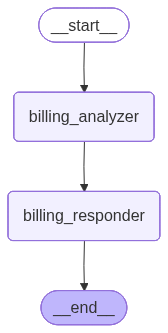

In [11]:
display(Image(billing_subgraph.get_graph().draw_mermaid_png()))

### Subgraph Technical (soporte técnico)


In [12]:
def tech_diagnostics(state: TicketState) -> dict:
    print("  🔧 TECH DIAGNOSTICS procesando...")

    full_context = f"Subject: {state['ticket_subject']}\n\nBody:\n{state['ticket_body']}"

    response = llm.invoke([
        SystemMessage(content=(
            "Eres un ingeniero de diagnóstico técnico senior.\n"
            "REGLA CRÍTICA: Solo menciona componentes, causas y síntomas que estén\n"
            "EXPLÍCITAMENTE mencionados en el texto del ticket. No inventes causas.\n"
            "Si el ticket no especifica la causa, escribe 'causa no especificada por el cliente'.\n"
            "Identifica: componentes afectados (según el ticket), severidad, pasos de diagnóstico.\n"
            f"{lang_instruction(state)}"
        )),
        HumanMessage(content=full_context)
    ])

    print(f"     Diagnóstico: {response.content[:80]}...")
    return {
        "analysis":       response.content,
        "agents_involved": ["tech_diagnostics"],
    }


def tech_solution_writer(state: TicketState) -> dict:
    print("  📝 TECH SOLUTION WRITER generando respuesta...")

    response = llm.invoke([
        SystemMessage(content=(
            "Eres un agente de soporte técnico.\n"
            "Escribe una respuesta clara basándote SOLO en el diagnóstico previo y el ticket original.\n"
            "Si la causa es desconocida, solicita más información al cliente en lugar de inventar.\n"
            "Máximo 200 palabras. Tono profesional.\n"
            f"{lang_instruction(state)}"
        )),
        HumanMessage(content=(
            f"DIAGNÓSTICO:\n{state.get('analysis', 'N/A')}\n\n"
            f"TICKET ORIGINAL:\n"
            f"Subject: {state['ticket_subject']}\n"
            f"Body:\n{state['ticket_body']}"
        ))
    ])

    print(f"     Solución generada ({len(response.content)} chars)")
    return {
        "draft_response":  response.content,
        "agents_involved": ["tech_solution_writer"],
    }


def build_technical_subgraph():
    builder = StateGraph(TicketState)
    builder.add_node("tech_diagnostics",     tech_diagnostics)
    builder.add_node("tech_solution_writer", tech_solution_writer)
    builder.add_edge(START, "tech_diagnostics")
    builder.add_edge("tech_diagnostics",     "tech_solution_writer")
    builder.add_edge("tech_solution_writer", END)
    return builder.compile()

technical_subgraph = build_technical_subgraph()
print("✅ technical_subgraph compilado (con grounding estricto)")

✅ technical_subgraph compilado (con grounding estricto)


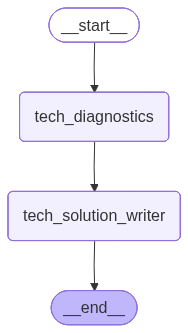

In [13]:
display(Image(technical_subgraph.get_graph().draw_mermaid_png()))

### Subgraph General

In [14]:
def general_responder(state: TicketState) -> dict:
    print("  🌐 GENERAL RESPONDER procesando...")

    response = llm.invoke([
        SystemMessage(content=(
            "Eres un agente de atención al cliente generalista.\n"
            "Responde de manera amable, informativa y concisa.\n"
            "Basa tu respuesta SOLO en la información del ticket. "
            "No asumas información no mencionada por el cliente.\n"
            "Máximo 150 palabras.\n"
            f"{lang_instruction(state)}"
        )),
        HumanMessage(content=(
            f"Subject: {state['ticket_subject']}\n\n"
            f"Body:\n{state['ticket_body']}"
        ))
    ])

    print(f"     Respuesta generada ({len(response.content)} chars)")
    return {
        "analysis":        "Consulta general procesada directamente",
        "draft_response":  response.content,
        "agents_involved": ["general_responder"],
    }


def build_general_subgraph():
    builder = StateGraph(TicketState)
    builder.add_node("general_responder", general_responder)
    builder.add_edge(START, "general_responder")
    builder.add_edge("general_responder", END)
    return builder.compile()

general_subgraph = build_general_subgraph()
print("✅ general_subgraph compilado (con idioma)")

✅ general_subgraph compilado (con idioma)


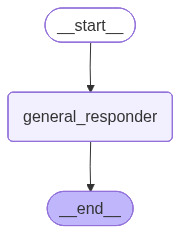

In [15]:
display(Image(general_subgraph.get_graph().draw_mermaid_png()))

###  Nodo final: Quality Checker

In [16]:
def quality_checker(state: TicketState) -> dict:
    print("\n✅ QUALITY CHECKER revisando respuesta final...")

    response = llm.invoke([
        SystemMessage(content=(
            "Eres un supervisor de calidad de atención al cliente.\n"
            "Revisa el borrador y haz mejoras mínimas:\n"
            "- Asegúrate que responde EXACTAMENTE la pregunta del ticket original\n"
            "- Elimina cualquier información que no sea relevante al ticket\n"
            "- Corrige el idioma si no coincide con el ticket del cliente\n"
            "Devuelve únicamente la respuesta final, sin comentarios.\n"
            f"{lang_instruction(state)}"
        )),
        HumanMessage(content=(
            f"BORRADOR:\n{state.get('draft_response', '')}\n\n"
            f"TICKET ORIGINAL:\n"
            f"Subject: {state['ticket_subject']}\n"
            f"Body:\n{state['ticket_body'][:400]}"
        ))
    ])

    print(f"   Respuesta final lista ({len(response.content)} chars)")
    return {
        "final_response":  response.content,
        "agents_involved": ["quality_checker"],
    }

print("✅ quality_checker definido (con idioma + relevance check)")

✅ quality_checker definido (con idioma + relevance check)


### Router condicional del Root Graph


In [17]:
# Celda 11: Router condicional
# Decide a qué subgraph derivar según la clasificación del root_orchestrator

def route_by_domain(state: TicketState) -> str:
    """Función de enrutamiento: mapea domain → nombre del nodo subgraph."""
    domain = state.get("domain", "general")
    route_map = {
        "billing":   "billing_subgraph",
        "technical": "technical_subgraph",
        "general":   "general_subgraph",
    }
    destination = route_map.get(domain, "general_subgraph")
    print(f"\n🔀 ROUTER → '{domain}' ➜ nodo '{destination}'")
    return destination

print("✅ route_by_domain definido")

✅ route_by_domain definido


### Construcción del Root Graph completo

In [18]:
root_builder = StateGraph(TicketState)

# ── Nodos del Root Graph ──────────────────────────────────────────────────────
root_builder.add_node("root_orchestrator",  root_orchestrator)
root_builder.add_node("billing_subgraph",   billing_subgraph)    # subgraph compilado
root_builder.add_node("technical_subgraph", technical_subgraph)  # subgraph compilado
root_builder.add_node("general_subgraph",   general_subgraph)    # subgraph compilado
root_builder.add_node("quality_checker",    quality_checker)

# ── Edges ─────────────────────────────────────────────────────────────────────
root_builder.add_edge(START, "root_orchestrator")

# Edge condicional: root_orchestrator → subgraph correspondiente
root_builder.add_conditional_edges(
    "root_orchestrator",
    route_by_domain,
    {
        "billing_subgraph":   "billing_subgraph",
        "technical_subgraph": "technical_subgraph",
        "general_subgraph":   "general_subgraph",
    }
)

# Todos los subgraphs convergen en quality_checker
root_builder.add_edge("billing_subgraph",   "quality_checker")
root_builder.add_edge("technical_subgraph", "quality_checker")
root_builder.add_edge("general_subgraph",   "quality_checker")

root_builder.add_edge("quality_checker", END)

# ── Compilar ──────────────────────────────────────────────────────────────────
graph = root_builder.compile()

print("✅ Root Graph compilado exitosamente")
print("\n📊 Arquitectura:")
print("   START")
print("   └─ root_orchestrator  (clasifica dominio)")
print("       ├─ billing_subgraph   → billing_analyzer → billing_responder")
print("       ├─ technical_subgraph → tech_diagnostics → tech_solution_writer")
print("       └─ general_subgraph   → general_responder")
print("           └─ quality_checker → END")

✅ Root Graph compilado exitosamente

📊 Arquitectura:
   START
   └─ root_orchestrator  (clasifica dominio)
       ├─ billing_subgraph   → billing_analyzer → billing_responder
       ├─ technical_subgraph → tech_diagnostics → tech_solution_writer
       └─ general_subgraph   → general_responder
           └─ quality_checker → END


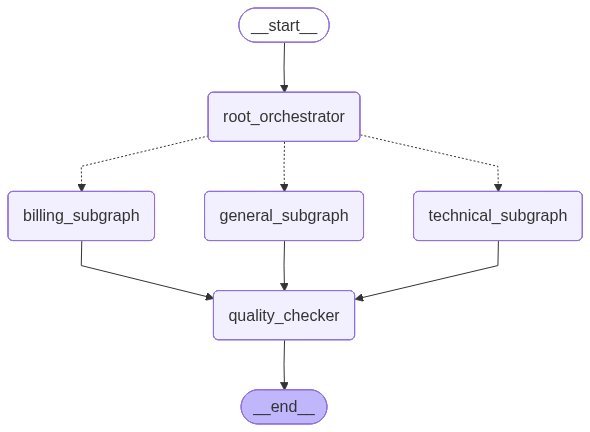

In [19]:
display(Image(graph.get_graph().draw_mermaid_png()))

### Función helper para procesar tickets del dataset

In [20]:
def process_ticket(ticket: pd.Series, verbose: bool = True) -> dict:
    """
    Procesa un ticket del dataset a través del sistema jerárquico de agentes.

    Args:
        ticket: Una fila del DataFrame con columnas del dataset
        verbose: Si True, imprime el progreso detallado

    Returns:
        dict con el estado final del sistema
    """
    print("=" * 70)
    print(f"🎫 TICKET: {ticket['subject'][:60]}")
    print(f"   Cola real: {ticket['queue']} | Tipo: {ticket['type']} | Prioridad: {ticket['priority']}")
    print(f"   Idioma: {ticket.get('language', 'en')}")
    print("=" * 70)

    initial_state: TicketState = {
        "ticket_subject":    str(ticket["subject"]),
        "ticket_body":       str(ticket["body"]),
        "ticket_language":   str(ticket.get("language", "en")),
        "domain":            None,
        "priority_detected": None,
        "analysis":          None,
        "draft_response":    None,
        "final_response":    None,
        "routing_reason":    None,
        "agents_involved":   [],
    }

    # Ejecutar el grafo
    result = graph.invoke(initial_state)

    print("\n" + "─" * 70)
    print("📊 RESULTADO FINAL:")
    print(f"   Dominio detectado:   {result.get('domain')}")
    print(f"   Prioridad detectada: {result.get('priority_detected')}")
    print(f"   Agentes involucrados: {' → '.join(result.get('agents_involved', []))}")
    print(f"\n📝 RESPUESTA GENERADA:")
    print(result.get("final_response", "Sin respuesta"))
    print("\n📝 RESPUESTA REAL DEL DATASET:")
    print(str(ticket.get("answer", "N/A"))[:300])
    print("=" * 70)

    return result

print("✅ process_ticket definido")

✅ process_ticket definido


In [21]:
# Celda 14: Demo — Ticket de Billing (facturación)

billing_ticket = df[df["queue"] == "Billing and Payments"].iloc[2]
result_billing = process_ticket(billing_ticket)

🎫 TICKET: Problem with Payment Billing Procedures
   Cola real: Billing and Payments | Tipo: Problem | Prioridad: medium
   Idioma: en

🏛️  ROOT ORCHESTRATOR procesando ticket...
   Subject:  Problem with Payment Billing Procedures...
   Idioma:   en
   ✅ Dominio: billing | Prioridad: high
   💬 Razón:   Customer reports billing inconsistencies and payment confirmation delays on their account.

🔀 ROUTER → 'billing' ➜ nodo 'billing_subgraph'
  💰 BILLING ANALYZER procesando...
     Análisis: **Problem Type:** Billing inconsistencies and payment confirmation delays.
**Ava...
  ✍️  BILLING RESPONDER generando respuesta...
     Respuesta generada (901 chars)

✅ QUALITY CHECKER revisando respuesta final...
   Respuesta final lista (678 chars)

──────────────────────────────────────────────────────────────────────
📊 RESULTADO FINAL:
   Dominio detectado:   billing
   Prioridad detectada: high
   Agentes involucrados: root_orchestrator → root_orchestrator → billing_analyzer → billing_responder 

In [22]:
# Celda 15: Demo — Ticket de Technical Support

technical_ticket = df[df["queue"] == "Technical Support"].iloc[0]
result_technical = process_ticket(technical_ticket)

🎫 TICKET: Wesentlicher Sicherheitsvorfall
   Cola real: Technical Support | Tipo: Incident | Prioridad: high
   Idioma: de

🏛️  ROOT ORCHESTRATOR procesando ticket...
   Subject:  Wesentlicher Sicherheitsvorfall...
   Idioma:   de
   ✅ Dominio: technical | Prioridad: critical
   💬 Razón:   Sicherheitsvorfall mit potenzieller Datenverletzung durch Cyberangriff auf mehrere Infrastrukturkomponenten

🔀 ROUTER → 'technical' ➜ nodo 'technical_subgraph'
  🔧 TECH DIAGNOSTICS procesando...
     Diagnóstico: # Technischer Diagnose-Bericht

## Ticket-Klassifizierung
**Betreff:** Wesentlic...
  📝 TECH SOLUTION WRITER generando respuesta...
     Solución generada (1200 chars)

✅ QUALITY CHECKER revisando respuesta final...
   Respuesta final lista (1168 chars)

──────────────────────────────────────────────────────────────────────
📊 RESULTADO FINAL:
   Dominio detectado:   technical
   Prioridad detectada: critical
   Agentes involucrados: root_orchestrator → root_orchestrator → tech_diagnostics → 

In [23]:
# Celda 16: Demo — Ticket General (Returns and Exchanges)

general_ticket = df[df["queue"] == "Returns and Exchanges"].iloc[0]
result_general = process_ticket(general_ticket)

🎫 TICKET: Query About Smart Home System Integration Features
   Cola real: Returns and Exchanges | Tipo: Request | Prioridad: medium
   Idioma: en

🏛️  ROOT ORCHESTRATOR procesando ticket...
   Subject:  Query About Smart Home System Integration Features...
   Idioma:   en
   ✅ Dominio: general | Prioridad: low
   💬 Razón:   Product information inquiry about smart home integration compatibility features

🔀 ROUTER → 'general' ➜ nodo 'general_subgraph'
  🌐 GENERAL RESPONDER procesando...
     Respuesta generada (916 chars)

✅ QUALITY CHECKER revisando respuesta final...
   Respuesta final lista (591 chars)

──────────────────────────────────────────────────────────────────────
📊 RESULTADO FINAL:
   Dominio detectado:   general
   Prioridad detectada: low
   Agentes involucrados: root_orchestrator → root_orchestrator → general_responder → quality_checker

📝 RESPUESTA GENERADA:
**Re: Query About Smart Home System Integration Features**

Dear Customer,

Thank you for reaching out to us!

To

In [24]:
import random

random.seed(42)

# Filtrar filas con datos válidos antes de samplear
df_clean = df.dropna(subset=["subject", "body", "answer"]).reset_index(drop=True)
sample_indices = random.sample(range(len(df_clean)), 5)

results = []
metrics = {"billing": 0, "technical": 0, "general": 0}

print(f"🚀 Procesando batch de 5 tickets (de {len(df_clean):,} tickets válidos)...\n")

for idx in range(len(sample_indices)):
    row_idx = sample_indices[idx]
    row = df_clean.iloc[row_idx]          # <- extraer la fila explícitamente

    # Crear un dict limpio con strings garantizados
    ticket_data = pd.Series({
        "subject":  str(row["subject"]),
        "body":     str(row["body"]),
        "answer":   str(row["answer"]),
        "queue":    str(row.get("queue", "Unknown")),
        "type":     str(row.get("type", "Unknown")),
        "priority": str(row.get("priority", "medium")),
        "language": str(row.get("language", "en")),
    })

    print(f"\n{'=' * 70}")
    print(f"📦 TICKET {idx + 1}/5")

    result = process_ticket(ticket_data, verbose=True)
    results.append(result)

    domain = result.get("domain", "general")
    metrics[domain] = metrics.get(domain, 0) + 1

print("\n" + "=" * 70)
print("📊 RESUMEN DEL BATCH:")
print(f"   Total tickets procesados: {len(results)}")
for domain_name, count in metrics.items():
    print(f"   {domain_name:12s}: {count} ticket(s)")

🚀 Procesando batch de 5 tickets (de 43,277 tickets válidos)...


📦 TICKET 1/5
🎫 TICKET: Zahlungsarten
   Cola real: Billing and Payments | Tipo: Request | Prioridad: medium
   Idioma: de

🏛️  ROOT ORCHESTRATOR procesando ticket...
   Subject:  Zahlungsarten...
   Idioma:   de
   ✅ Dominio: billing | Prioridad: low
   💬 Razón:   Cliente consulta métodos de pago aceptados y posibles descuentos en suscripciones, sin incidencia activa.

🔀 ROUTER → 'billing' ➜ nodo 'billing_subgraph'
  💰 BILLING ANALYZER procesando...
     Análisis: **Analyse des Tickets**

**Problemtyp:** Allgemeine Informationsanfrage zu Zahlu...
  ✍️  BILLING RESPONDER generando respuesta...
     Respuesta generada (857 chars)

✅ QUALITY CHECKER revisando respuesta final...
   Respuesta final lista (699 chars)

──────────────────────────────────────────────────────────────────────
📊 RESULTADO FINAL:
   Dominio detectado:   billing
   Prioridad detectada: low
   Agentes involucrados: root_orchestrator → root_orchestrator 

In [25]:
import re

def extract_json_safe(text: str) -> dict:
    """
    Extrae JSON de una respuesta LLM de manera robusta.
    Maneja: backticks markdown, texto previo/posterior, comillas simples.
    """
    # 1. Remover backticks markdown si existen
    text = re.sub(r"```(?:json)?", "", text).strip()

    # 2. Intentar parseo directo
    try:
        return json.loads(text)
    except json.JSONDecodeError:
        pass

    # 3. Buscar el primer bloque {...} en el texto
    match = re.search(r"\{.*?\}", text, re.DOTALL)
    if match:
        try:
            return json.loads(match.group())
        except json.JSONDecodeError:
            pass

    # 4. Fallback: retornar error descriptivo
    return {"error": f"No se pudo parsear: {text[:80]}"}


def compare_responses(original_answer: str, generated_answer: str) -> dict:
    """Usa el LLM para comparar las respuestas generada vs real del dataset."""
    response = llm.invoke([
        SystemMessage(content=(
            "Eres un evaluador de calidad de respuestas de soporte.\n"
            "Compara dos respuestas al mismo ticket y evalúa en escala 0-10:\n"
            "- completitud: ¿La generada cubre lo mismo que la real?\n"
            "- profesionalismo: ¿Tono y formato adecuados?\n"
            "- accionabilidad: ¿Da pasos concretos al cliente?\n\n"
            "IMPORTANTE: Responde ÚNICAMENTE con el JSON, sin backticks, sin texto adicional:\n"
            '{"completitud": 7, "profesionalismo": 8, "accionabilidad": 6, "comentario": "breve"}'
        )),
        HumanMessage(content=(
            f"RESPUESTA REAL:\n{original_answer[:400]}\n\n"
            f"RESPUESTA GENERADA:\n{generated_answer[:400]}"
        ))
    ])

    return extract_json_safe(response.content.strip())


# ── Ejecutar evaluación ──────────────────────────────────────────────────────
print("📈 EVALUACIÓN DE CALIDAD (Agente vs Dataset real)\n")
print(f"{'Ticket':<8} {'Dominio':<12} {'Complet.':<10} {'Profes.':<10} {'Acción':<10} {'Promedio':<10}")
print("-" * 65)

scores_list = []

# results  → lista generada en Celda 17 (un dict por ticket procesado)
# sample_indices → lista de índices generada en Celda 17
# df_clean → DataFrame limpio generado en Celda 17
for i, result in enumerate(results):
    row = df_clean.iloc[sample_indices[i]]          # recuperar la fila original
    original  = str(row.get("answer", ""))
    generated = str(result.get("final_response", ""))

    scores = compare_responses(original, generated)

    if "error" not in scores:
        avg = (
            scores["completitud"] +
            scores["profesionalismo"] +
            scores["accionabilidad"]
        ) / 3
        scores_list.append(avg)
        print(
            f"{i+1:<8} {result.get('domain', 'N/A'):<12} "
            f"{scores['completitud']:<10} {scores['profesionalismo']:<10} "
            f"{scores['accionabilidad']:<10} {avg:.1f}"
        )
        if scores.get("comentario"):
            print(f"         💬 {scores['comentario'][:70]}")
    else:
        print(f"{i+1:<8} {result.get('domain', 'N/A'):<12} ⚠️  {scores['error'][:50]}")

if scores_list:
    print(f"\n{'─' * 65}")
    print(f"{'PROMEDIO GLOBAL':<20} {sum(scores_list)/len(scores_list):.1f}/10")

print("\n✅ Evaluación completada")

📈 EVALUACIÓN DE CALIDAD (Agente vs Dataset real)

Ticket   Dominio      Complet.   Profes.    Acción     Promedio  
-----------------------------------------------------------------
1        billing      3          7          2          4.0
         💬 La respuesta generada está incompleta (cortada) y no proporciona la in
2        general      3          7          5          5.0
         💬 La respuesta generada no cubre el contenido real: en lugar de proporci
3        technical    5          8          6          6.3
         💬 La respuesta generada solicita información adicional en lugar de propo
4        technical    8          9          8          8.3
         💬 La respuesta generada es más estructurada y profesional, solicita info
5        general      8          9          6          7.7
         💬 La respuesta generada cubre los temas principales (analytics, herramie

─────────────────────────────────────────────────────────────────
PROMEDIO GLOBAL      6.3/10

✅ Evaluación comp

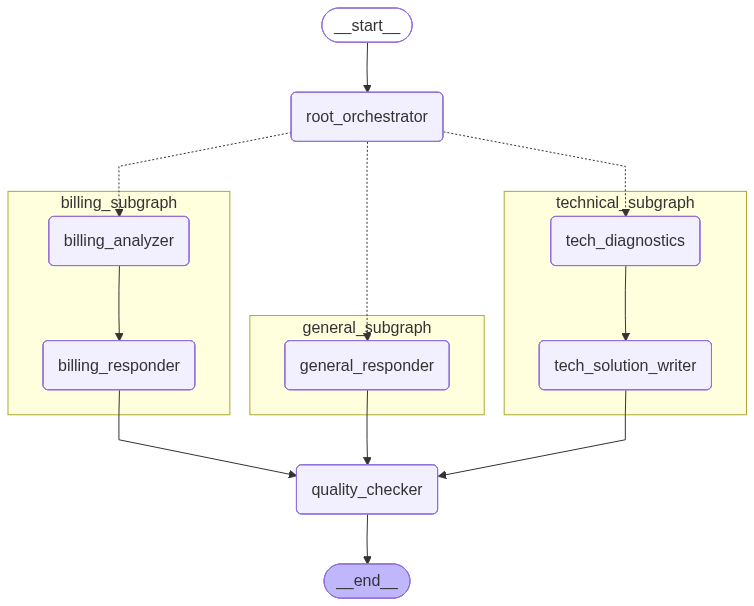

✅ Grafo renderizado


In [26]:
# Celda 19: Visualización del grafo (Mermaid)

try:
    from IPython.display import display, Image
    img = graph.get_graph(xray=True).draw_mermaid_png()
    display(Image(img))
    print("✅ Grafo renderizado")
except Exception as e:
    # Fallback: imprimir Mermaid textual
    print("ℹ️  Renderizado visual no disponible. Diagrama Mermaid:\n")
    print("""graph TD
    START([__start__]) --> ROOT_ORCH

    ROOT_ORCH["🏛️ Root Orchestrator\\n(clasifica dominio)"]

    ROOT_ORCH -->|"domain=billing"| BILLING["💰 Billing Subgraph"]
    ROOT_ORCH -->|"domain=technical"| TECHNICAL["🔧 Technical Subgraph"]
    ROOT_ORCH -->|"domain=general"| GENERAL["🌐 General Subgraph"]

    subgraph Billing Subgraph
        BA["💰 Billing Analyzer"] --> BR["✍️ Billing Responder"]
    end

    subgraph Technical Subgraph
        TD["🔧 Tech Diagnostics"] --> TS["📝 Tech Solution Writer"]
    end

    subgraph General Subgraph
        GR["🌐 General Responder"]
    end

    BILLING --> QC["✅ Quality Checker"]
    TECHNICAL --> QC
    GENERAL --> QC
    QC --> END([__end__])
    """)

In [27]:
mi_ticket = {
    "subject": "Cobro duplicado en mi factura de enero",
    "body": (
        "Hola, estoy revisando mi estado de cuenta y noto que me cobraron "
        "dos veces el monto de $150.00 correspondiente a la suscripción mensual "
        "del mes de enero 2025. Las transacciones tienen fechas del 3 y 5 de enero. "
        "Necesito que me hagan el reembolso del cargo duplicado lo antes posible. "
        "Mi número de cuenta es ACC-78934. Gracias."
    ),
    "queue": "Billing and Payments",  # referencia, no se usa en el agente
    "type": "Problem",
    "priority": "high",
    "language": "es",
    "answer": "N/A",
}

result_custom = process_ticket(pd.Series(mi_ticket))

print(f"\n🏷️  Agentes involucrados:")
for agente in result_custom["agents_involved"]:
    print(f"   → {agente}")

🎫 TICKET: Cobro duplicado en mi factura de enero
   Cola real: Billing and Payments | Tipo: Problem | Prioridad: high
   Idioma: es

🏛️  ROOT ORCHESTRATOR procesando ticket...
   Subject:  Cobro duplicado en mi factura de enero...
   Idioma:   es
   ✅ Dominio: billing | Prioridad: high
   💬 Razón:   Cargo duplicado de $150.00 en suscripción mensual, cliente solicita reembolso urgente con número de cuenta identificado.

🔀 ROUTER → 'billing' ➜ nodo 'billing_subgraph'
  💰 BILLING ANALYZER procesando...
     Análisis: **Analysis:**
**Problem Type:** Duplicate charge — subscription fee of $150.00 b...
  ✍️  BILLING RESPONDER generando respuesta...
     Respuesta generada (818 chars)

✅ QUALITY CHECKER revisando respuesta final...
   Respuesta final lista (654 chars)

──────────────────────────────────────────────────────────────────────
📊 RESULTADO FINAL:
   Dominio detectado:   billing
   Prioridad detectada: high
   Agentes involucrados: root_orchestrator → root_orchestrator → billing_ana